# CatBoost Optimized Baseline & GPU Optuna Tuning - PS-S06E08

This notebook implements an optimized GPU-accelerated **CatBoost** classifier with SQLite-backed Optuna hyperparameter tuning for **Playground Series – Season 6, Episode 8: Predicting Smartphone Addiction**.

We employ Stratified 5-Fold cross-validation, 5-seed training, full feature engineering (ratios, interactions, group aggregations), and out-of-fold probability exporting for the 4-Model Stacking Ensemble.

**Key Architecture & Optimization Strategy**:
1. **Engineered Interaction Features**: CatBoost's symmetric (oblivious) trees rely heavily on explicit numerical ratios and interaction terms (`daily_screen_time_hours / sleep_hours`, `social_media_hours / daily_screen_time_hours`, etc.) to break tree symmetry.
2. **Proper Categorical Encoding**: Categorical variables (`gender`, `stress_level`, `academic_work_impact`) are explicitly passed to `cb.Pool(..., cat_features=cat_cols)`.
3. **GPU Hyperparameters**: Oblivious trees require deeper depths (`depth=7..8`), slower learning rates (`learning_rate=0.03..0.05`), and higher iteration counts (`iterations=5000`) for smooth convergence.
4. **Diagnostics & Visualization**: Full learning curves, feature importances, ROC curve, and confusion matrix integrated via `ModelVisualizer`.

## 1. Setup & Imports

In [1]:
import os
import gc
import sys
import json
import math
import time
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import catboost as cb
from catboost import Pool
import optuna
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score

from ps_s06e08_experiment_setup import ExperimentSetup
from ps_s06e08_feature_engineering import FeatureFactory
from ps_s06e08_model_visualizer import ModelVisualizer

warnings.filterwarnings('ignore')
%matplotlib inline

## 2. Configuration & Experiment Setup

In [2]:
MODEL_PREFIX = "cb"
N_SPLITS = 5

setup = ExperimentSetup(
    model_name='CatBoost',
    use_gpu=True,  # Set to True on GPU-enabled environments
    perform_rfe=False,
    perform_optuna_tuning=False
)

seed = setup.set_seeds()
setup.configure_pandas()
setup.suppress_warnings()

TARGET = 'addicted_label'

Random seed set to: 10301
Warnings suppressed.


## 3. Data Loading & Feature Engineering

In [3]:
training_df = setup.read_dataset('training')
test_df = setup.read_dataset('test')

train_ids = training_df['id'].copy()
test_ids = test_df['id'].copy()

print(f"Raw Train shape: {training_df.shape}, Test shape: {test_df.shape}")

# CatBoost oblivious trees perform significantly better with explicit interaction and ratio features
fe_strategies = [
    'encoding',
    'screen_time_ratios',
    'sleep_stress',
    'risk_score',
    'missing_flags',
]

factory = FeatureFactory(
    strategies=fe_strategies,
    impute_strategy='median_mode',
    target=TARGET,
    verbose=True
)

y = training_df[TARGET].copy()

X = factory.fit_transform(training_df)
X_test = factory.transform(test_df)

print(f"Train features shape: {X.shape}")
print(f"Test features shape: {X_test.shape}")

# Identify categorical columns for CatBoost Pool
raw_cat_cols = ['gender', 'stress_level', 'academic_work_impact']
cat_cols = [c for c in raw_cat_cols if c in X.columns]
print(f"Categorical features for CatBoost Pool: {cat_cols}")

TRAINING DATASET

   id    age  daily_screen_time_hours  social_media_hours  gaming_hours  \
0   0 24.000                      NaN               1.830         1.590   
1   1 19.000                    5.970               1.080           NaN   
2   2 18.000                    5.090                 NaN           NaN   
3   3 21.000                    6.420               1.260         1.420   
4   4 26.000                   11.200               1.870         2.810   

   work_study_hours  sleep_hours  notifications_per_day  app_opens_per_day  \
0             2.110        7.460                122.000             38.000   
1             3.030        8.220                 76.000             19.000   
2               NaN        6.250                134.000             60.000   
3             3.360        8.850                112.000             94.000   
4             1.950        5.250                    NaN                NaN   

   weekend_screen_time  gender stress_level academic_work_impa

## 4. SQLite-Backed Optuna Optimization

Tunes CatBoost hyperparameters over a 5-fold CV split, caching trials dynamically in an SQLite database `catboost_study.db`.

In [4]:
optuna_filename = 'optuna_params_catboost.json'
best_params = setup.load_optuna_params(optuna_filename)

if setup.perform_optuna_tuning():
    print("Starting CatBoost SQLite Optuna Optimization (GPU Deep Search)...")

    pruner = optuna.pruners.MedianPruner(
        n_startup_trials=5,
        n_warmup_steps=3,
        interval_steps=1
    )

    study = optuna.create_study(
        storage='sqlite:///catboost_study_v4.db',
        load_if_exists=True,
        direction='maximize',
        study_name='cb_feature_engineered_optuna_v4',
        pruner=pruner,
        sampler=optuna.samplers.TPESampler(
            seed=seed,
            n_startup_trials=5,
            multivariate=True
        )
    )

    skf_cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=seed)
    fold_cache = []
    for tr_idx, val_idx in skf_cv.split(X, y):
        fold_cache.append((tr_idx, val_idx))

    def objective(trial):
        grow_policy = trial.suggest_categorical('grow_policy', ['SymmetricTree', 'Lossguide'])
        params = {
            'iterations': 4000,
            'loss_function': 'Logloss',
            'eval_metric': 'AUC',
            'metric_period': 5 if setup.use_gpu() else 1,
            'task_type': 'GPU' if setup.use_gpu() else 'CPU',
            'random_seed': seed,
            'allow_writing_files': False,
            'verbose': False,
            'one_hot_max_size': 10,
            'border_count': 254,
            'grow_policy': grow_policy,
            'depth': trial.suggest_int('depth', 4, 8),
            'learning_rate': trial.suggest_float('learning_rate', 0.02, 0.08, log=True),
            'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1.0, 10.0, log=True),
            'random_strength': trial.suggest_float('random_strength', 1.0, 8.0),
            'min_data_in_leaf': trial.suggest_int('min_data_in_leaf', 10, 300, log=True),
            'leaf_estimation_iterations': trial.suggest_int('leaf_estimation_iterations', 5, 15),
            'bootstrap_type': 'Bernoulli',
            'subsample': trial.suggest_float('subsample', 0.65, 1.0)
        }
        if grow_policy == 'Lossguide':
            params['max_leaves'] = trial.suggest_int('max_leaves', 24, 96)

        oof_preds = np.full(len(y), -1.0, dtype=float)

        for fold, (tr_idx, val_idx) in enumerate(fold_cache):
            X_tr, y_tr = X.iloc[tr_idx], y.iloc[tr_idx]
            X_val, y_val = X.iloc[val_idx], y.iloc[val_idx]

            X_tr_str = X_tr.copy()
            X_val_str = X_val.copy()
            for col in cat_cols:
                X_tr_str[col] = X_tr_str[col].astype(str)
                X_val_str[col] = X_val_str[col].astype(str)

            train_pool = Pool(X_tr_str, y_tr, cat_features=cat_cols if cat_cols else None)
            val_pool = Pool(X_val_str, y_val, cat_features=cat_cols if cat_cols else None)

            model = cb.CatBoostClassifier(**params)
            model.fit(
                train_pool,
                eval_set=val_pool,
                early_stopping_rounds=150,
                verbose=False
            )

            oof_preds[val_idx] = model.predict_proba(val_pool)[:, 1]

            intermediate_val = roc_auc_score(y_val, oof_preds[val_idx])
            trial.report(intermediate_val, fold)
            if trial.should_prune():
                raise optuna.exceptions.TrialPruned()

        return roc_auc_score(y, oof_preds)

    study.optimize(
        objective,
        n_trials=30,
        timeout=7200,
        show_progress_bar=True
    )

    best_params = study.best_params
    best_params['bootstrap_type'] = 'Bernoulli'
    print("Best CatBoost params found:", best_params)
    setup.save_optuna_params(optuna_filename, best_params)
    setup.upload_artifact(optuna_filename)
else:
    if not best_params:
        best_params = {
            'grow_policy': 'Lossguide',
            'max_leaves': 48,
            'depth': 6,
            'learning_rate': 0.045,
            'l2_leaf_reg': 5.0,
            'random_strength': 1.0,
            'one_hot_max_size': 10,
            'border_count': 254,
            'min_data_in_leaf': 100,
            'leaf_estimation_iterations': 10,
            'bootstrap_type': 'Bernoulli',
            'subsample': 0.8
        }
    print("Using loaded parameters:", best_params)

Loaded 10 parameters from optuna_params_catboost.json
Starting CatBoost SQLite Optuna Optimization (GPU Deep Search)...


[I 2026-08-19 14:15:54,794] A new study created in RDB with name: cb_feature_engineered_optuna_v4


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2026-08-19 14:21:34,667] Trial 0 finished with value: 0.9626810387936968 and parameters: {'grow_policy': 'SymmetricTree', 'depth': 8, 'learning_rate': 0.0567541179027997, 'l2_leaf_reg': 2.0358864728069035, 'random_strength': 6.35282715877275, 'min_data_in_leaf': 298, 'leaf_estimation_iterations': 12, 'subsample': 0.8295105449077599}. Best is trial 0 with value: 0.9626810387936968.
[I 2026-08-19 14:26:18,367] Trial 1 finished with value: 0.9637391091539841 and parameters: {'grow_policy': 'Lossguide', 'depth': 6, 'learning_rate': 0.04135875800738832, 'l2_leaf_reg': 5.021713626231377, 'random_strength': 1.1308974605136854, 'min_data_in_leaf': 146, 'leaf_estimation_iterations': 12, 'subsample': 0.8051096285856979, 'max_leaves': 61}. Best is trial 1 with value: 0.9637391091539841.
[I 2026-08-19 14:29:26,370] Trial 2 finished with value: 0.9636373641119583 and parameters: {'grow_policy': 'Lossguide', 'depth': 4, 'learning_rate': 0.04457868757180045, 'l2_leaf_reg': 7.871030289319035, 'rand

100%|██████████| 1.78k/1.78k [00:00<00:00, 4.74MB/s]


...

Upload successful: optuna_params_catboost.json (313B)
Starting upload for file optuna_params_xgb.json


100%|██████████| 283/283 [00:00<00:00, 405B/s]  


Upload successful: optuna_params_xgb.json (283B)
Starting upload for file selected_features_xgb.json


100%|██████████| 1.11k/1.11k [00:00<00:00, 1.91kB/s]


Upload successful: selected_features_xgb.json (1KB)
Dataset version is being created. Please check progress at https://www.kaggle.com/datasets/stephentarter/ps-s06e08-artifacts
Kaggle artifacts dataset upload completed successfully!


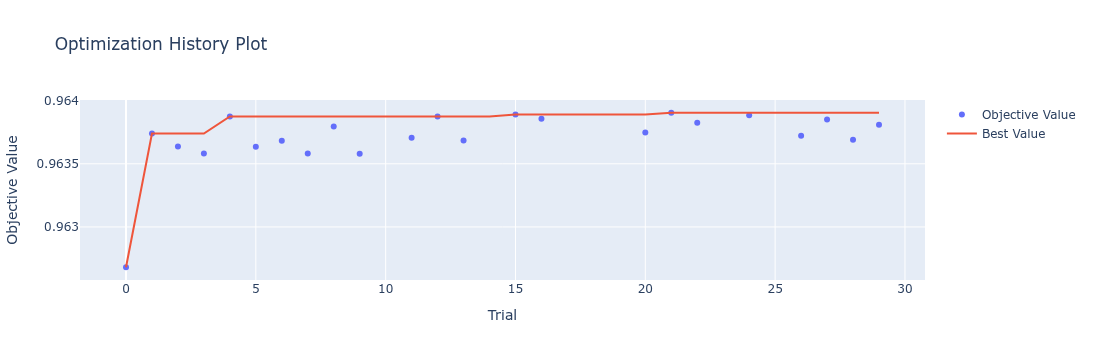

In [11]:
try:
    fig = optuna.visualization.plot_optimization_history(study)
    fig.show()
except NameError:
    print("Optuna wasn't run")

## 5. Model Training & Multi-Seed Blending

Trains the final seed-averaged models on the optimal parameters.

In [5]:
seeds = setup.seed()

oof_probs = np.zeros((len(X), 2))
test_probs = np.zeros((len(X_test), 2))
filled_mask = np.zeros(len(X), dtype=bool)

models = []
eval_results = []

for s_idx, current_seed in enumerate(seeds):
    print(f"================ SEED RUN {s_idx + 1}/{len(seeds)}: seed={current_seed} ================")

    cb_params = {
        'one_hot_max_size': 10,
        'border_count': 254,
        'bootstrap_type': 'Bernoulli',
        'metric_period': 5 if setup.use_gpu() else 1,
        **best_params,
        'iterations': 5000,
        'loss_function': 'Logloss',
        'eval_metric': 'AUC',
        'task_type': 'GPU' if setup.use_gpu() else 'CPU',
        'random_seed': current_seed,
        'allow_writing_files': False,
        'verbose': False
    }

    skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=current_seed)

    oof_probs_seed = np.zeros((len(X), 2))
    test_probs_seed = np.zeros((len(X_test), 2))

    for fold, (tr_idx, val_idx) in enumerate(skf.split(X, y)):
        X_tr, y_tr = X.iloc[tr_idx], y.iloc[tr_idx]
        X_val, y_val = X.iloc[val_idx], y.iloc[val_idx]

        X_tr_str = X_tr.copy()
        X_val_str = X_val.copy()
        X_test_str = X_test.copy()

        for col in cat_cols:
            X_tr_str[col] = X_tr_str[col].astype(str)
            X_val_str[col] = X_val_str[col].astype(str)
            X_test_str[col] = X_test_str[col].astype(str)

        train_pool = Pool(X_tr_str, y_tr, cat_features=cat_cols if cat_cols else None)
        val_pool = Pool(X_val_str, y_val, cat_features=cat_cols if cat_cols else None)
        test_pool = Pool(X_test_str, cat_features=cat_cols if cat_cols else None)

        model = cb.CatBoostClassifier(**cb_params)
        model.fit(
            train_pool,
            eval_set=val_pool,
            early_stopping_rounds=150,
            verbose=False
        )

        val_probs = model.predict_proba(val_pool)
        oof_probs_seed[val_idx] = val_probs
        filled_mask[val_idx] = True

        test_probs_seed += model.predict_proba(test_pool) / N_SPLITS

        fold_score = roc_auc_score(y_val, val_probs[:, 1])
        n_trees = model.tree_count_
        print(f"  Fold {fold+1} ROC AUC: {fold_score:.6f} (trees={n_trees})")

        models.append(model)
        eval_results.append(model.get_evals_result())

    seed_score = roc_auc_score(y, oof_probs_seed[:, 1])
    print(f"--- Seed {current_seed} CV ROC AUC: {seed_score:.6f} ---")

    oof_probs += oof_probs_seed / len(seeds)
    test_probs += test_probs_seed / len(seeds)

overall_score = roc_auc_score(y[filled_mask], oof_probs[filled_mask, 1])
print("="*60)
print(f"CatBoost Seed-Averaged CV ROC AUC: {overall_score:.6f}")
print("="*60)

================ SEED RUN 1/5: seed=10301 ================
  Fold 1 ROC AUC: 0.963269 (trees=4673)
  Fold 2 ROC AUC: 0.963932 (trees=4424)
  Fold 3 ROC AUC: 0.964260 (trees=3603)
  Fold 4 ROC AUC: 0.964149 (trees=4000)
  Fold 5 ROC AUC: 0.963856 (trees=3717)
--- Seed 10301 CV ROC AUC: 0.963890 ---
================ SEED RUN 2/5: seed=42 ================
  Fold 1 ROC AUC: 0.963214 (trees=3509)
  Fold 2 ROC AUC: 0.963857 (trees=4040)
  Fold 3 ROC AUC: 0.964148 (trees=3801)
  Fold 4 ROC AUC: 0.964938 (trees=4349)
  Fold 5 ROC AUC: 0.963543 (trees=3528)
--- Seed 42 CV ROC AUC: 0.963941 ---
================ SEED RUN 3/5: seed=2026 ================
  Fold 1 ROC AUC: 0.963078 (trees=4450)
  Fold 2 ROC AUC: 0.964561 (trees=4530)
  Fold 3 ROC AUC: 0.964525 (trees=4125)
  Fold 4 ROC AUC: 0.963862 (trees=4338)
  Fold 5 ROC AUC: 0.962850 (trees=3435)
--- Seed 2026 CV ROC AUC: 0.963774 ---
================ SEED RUN 4/5: seed=777 ================
  Fold 1 ROC AUC: 0.964303 (trees=3874)
  Fold 2 ROC A

## 6. Performance Visualization

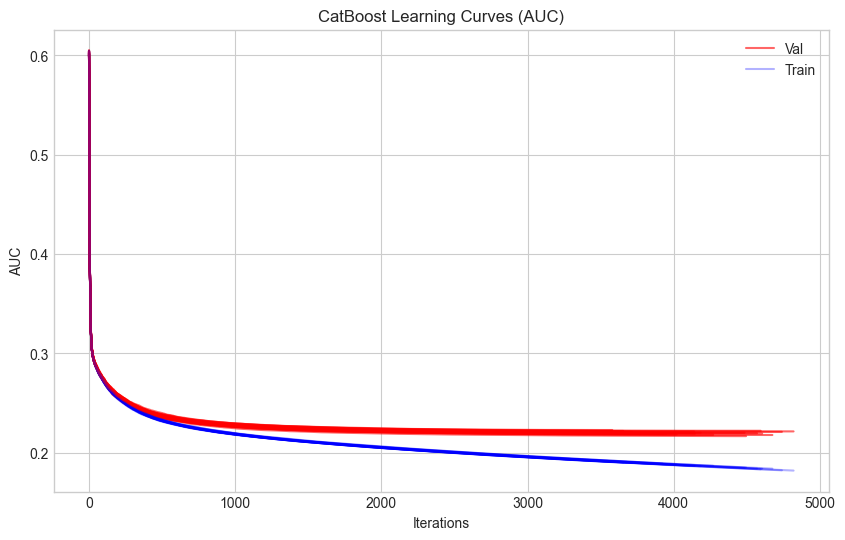

In [6]:
mviz = ModelVisualizer(model_name='CatBoost')

# Learning curves
mviz.plot_learning_curves(eval_results, metric='auc', metric_period=5 if setup.use_gpu() else 1)

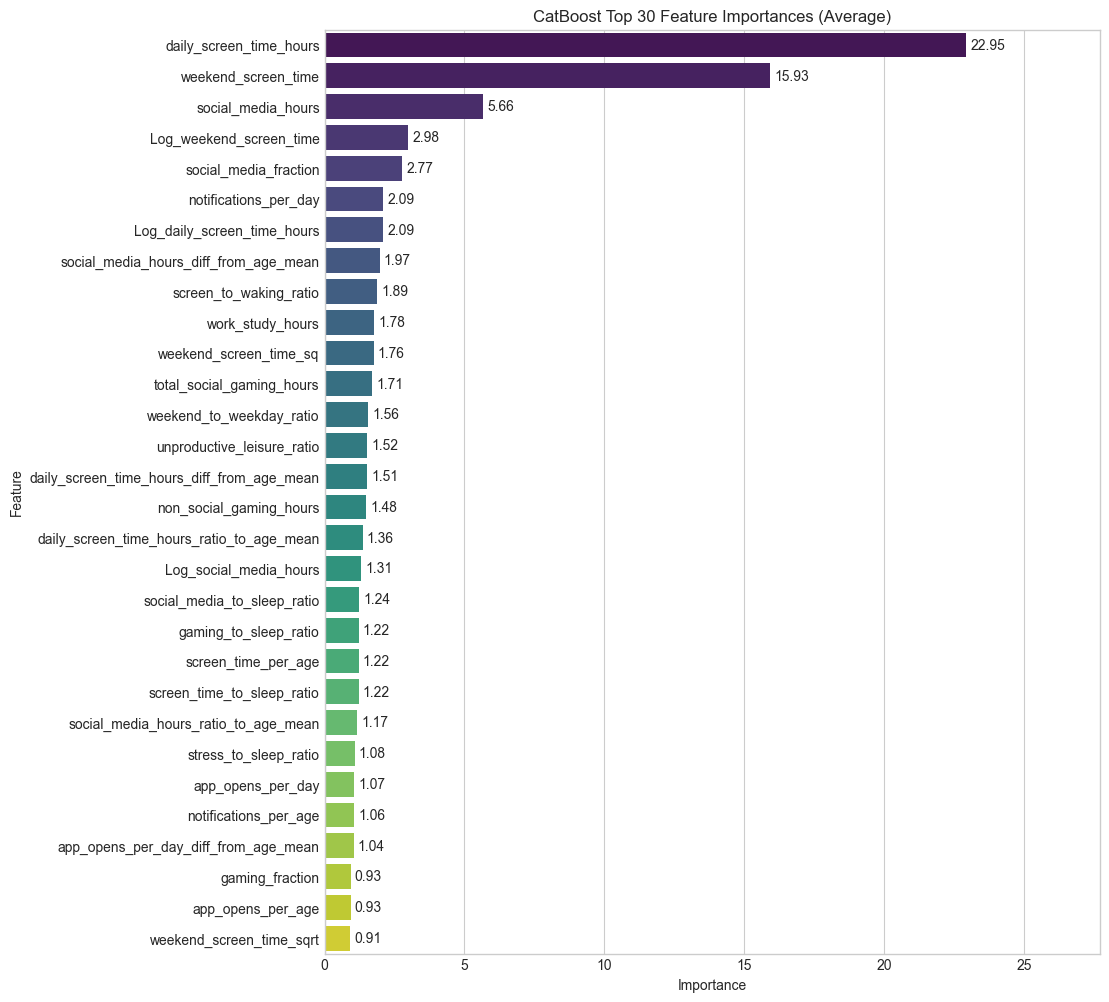

In [7]:
# Feature importances
mviz.plot_feature_importance(models, top_n=30, show_values=True)

<Figure size 800x600 with 0 Axes>

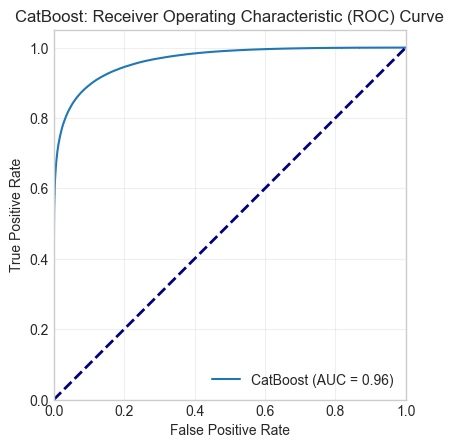

In [8]:
# Out-of-fold ROC curve
mviz.plot_roc_curve(y_true=y[filled_mask], y_score=oof_probs[filled_mask, 1])

Confusion matrix, without normalization


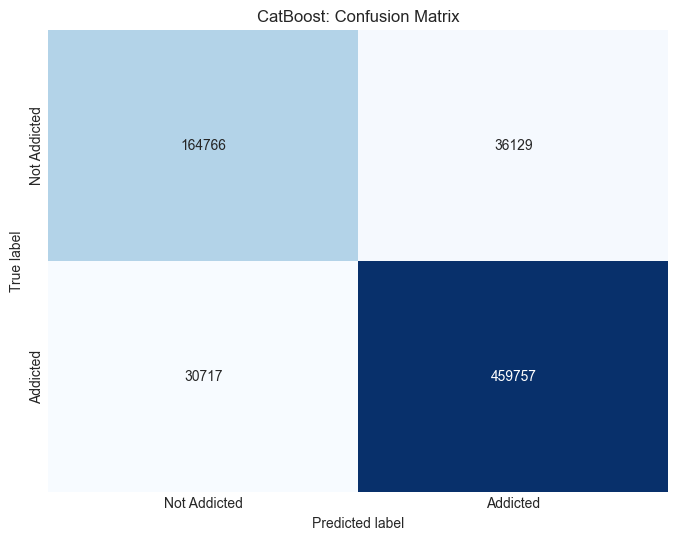

In [9]:
# Confusion matrix
y_pred_class = (oof_probs[:, 1] > 0.5).astype(int)
mviz.plot_confusion_matrix(
    y_true=y[filled_mask],
    y_pred=y_pred_class[filled_mask],
    classes=['Not Addicted', 'Addicted']
)

## 7. Export Submission & Predictions

In [10]:
setup.save_probabilities(
    MODEL_PREFIX,
    oof_probs,
    train_ids,
    y,
    filled_mask,
    test_probs,
    test_ids
)

submission_df = pd.DataFrame({
    'id': test_ids,
    'addicted_label': test_probs[:, 1]
})
submission_df.to_csv('submission.csv', index=False)
print("Saved CatBoost submission.csv successfully!")

Saved for ensembling:
 - predictions/cb_oof_probs.csv
 - predictions/cb_test_probs.csv
Saved CatBoost submission.csv successfully!
